# Setup dell'ambiente spark in colab

In [1]:
#installazione di java (prerequisito per spark)
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

#download di apache spark
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

#decompressione dell'archivio di spark
!tar xf spark-3.5.1-bin-hadoop3.tgz

#setting variabili d'ambiente (dove trovare java e spark)
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

#installazione della libreria findspark per trovare spark
!pip install -q findspark

#creazione della SparkSession
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local[*]")\
        .appName("WikipediaAnalysisColab")\
        .getOrCreate()

!pip install wordcloud

print(">>>>>>>>>>Setup ok. La SparkSession è attiva e la variabile spark è stata creata")

>>>>>>>>>>Setup ok. La SparkSession è attiva e la variabile spark è stata creata


# Import librerie

In [2]:
#spark
from pyspark.sql.functions import col, split, size, avg, min, max, concat_ws, explode, lower
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

#visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd

from pyspark.sql.functions import col, split, size, avg, min, max, concat_ws, explode, lower, round, count, when

# Caricamento e preparazione dei dati

In [3]:
#utilizzo un approccio spark-nativo che è più performante ed efficiente
# rispetto al passaggio intermedio con pandas, specialmente su dataset di grandi dimensioni.

#download file csv nell'ambiente locale di colab
!wget https://proai-datasets.s3.eu-west-3.amazonaws.com/wikipedia.csv


#definizione della variabile con il file
file_path = 'wikipedia.csv'


#lettura csv in locale con spark
df = spark.read.csv(file_path,
                    header=True,
                    inferSchema=True,
                    sep=',',
                    multiLine=True,
                    escape='"')

print(">>>>>>> File caricato in un dataframe spark")


df = df.withColumnRenamed("categoria", "label")

# normalizzazione delle colonne testuali per evitare problemi di case-sensitivity
df = df.withColumn("label", lower(col("label")))
print("\n>>>>>>Colonna 'label' normalizzata")

df.show(5, truncate=50)


--2025-08-03 18:26:31--  https://proai-datasets.s3.eu-west-3.amazonaws.com/wikipedia.csv
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.204.164, 3.5.205.228
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.204.164|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1003477941 (957M) [text/csv]
Saving to: ‘wikipedia.csv.1’

wikipedia.csv.1     100%[===================>] 956.99M  35.6MB/s    in 27s     

2025-08-03 18:26:59 (34.8 MB/s) - ‘wikipedia.csv.1’ saved [1003477941/1003477941]

>>>>>>> File caricato in un dataframe spark

>>>>>>Colonna 'label' normalizzata
+---+---------------------------+--------------------------------------------------+--------------------------------------------------+---------+
|_c0|                      title|                                           summary|                                         documents|    label|
+---+-

# Analisi esplorativa dei dati


>>>>>>>nalisi descrittiva
Conteggio degli articoli per categoria:
+-----------+-----+
|      label|count|
+-----------+-----+
|   politics|11358|
|    culture|10372|
|    science|10236|
| humanities|10236|
|engineering|10220|
|    finance|10157|
|  transport|10130|
|  economics|10110|
| technology|10095|
|   medicine|10076|
|      trade|10068|
|     sports|10068|
|     energy|10046|
|   research|10037|
|       pets|10023|
+-----------+-----+



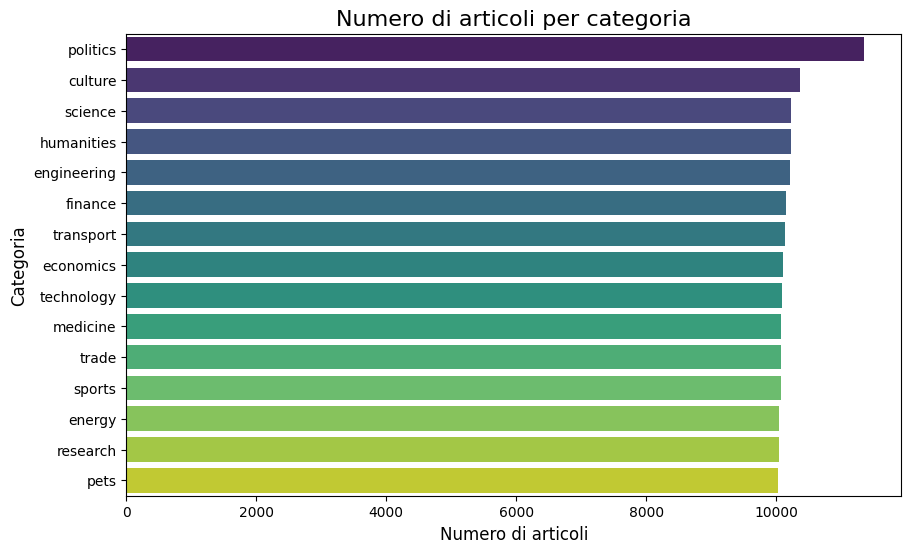


>>>>><  pulizia dei record con campo 'documents' nullo...
>>>Record totali prima della pulizia: 153232
>>>>>>Record totali dopo la pulizia: 152304
>>>>>>>> Record rimossi: 928
Pulizia andata a buon fine. Da ora in poi uso il dataframe pulito

>>>><<Analisi della lunghezza degli articoli per categoria:
+-----------+--------------+--------------+--------------+
|      label|Min Word Count|Max Word Count|Avg Word Count|
+-----------+--------------+--------------+--------------+
|    finance|             3|         33479|       1909.89|
|    science|            15|         29419|       1875.62|
|   politics|            11|         20140|       1515.65|
| humanities|             7|         23198|       1059.73|
|  economics|            10|         24022|         984.2|
| technology|             2|         18144|        889.23|
|   medicine|            12|         18422|        792.15|
|engineering|             8|         11856|        725.11|
|   research|            17|         27223|    

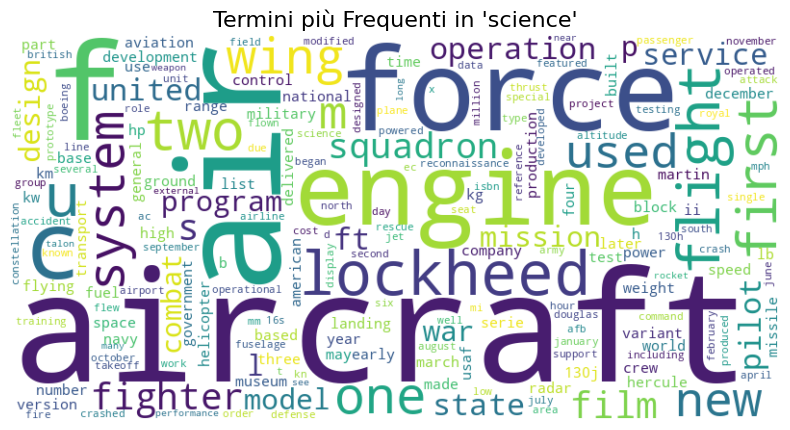


Generazione Word Cloud per la categoria: 'politics'


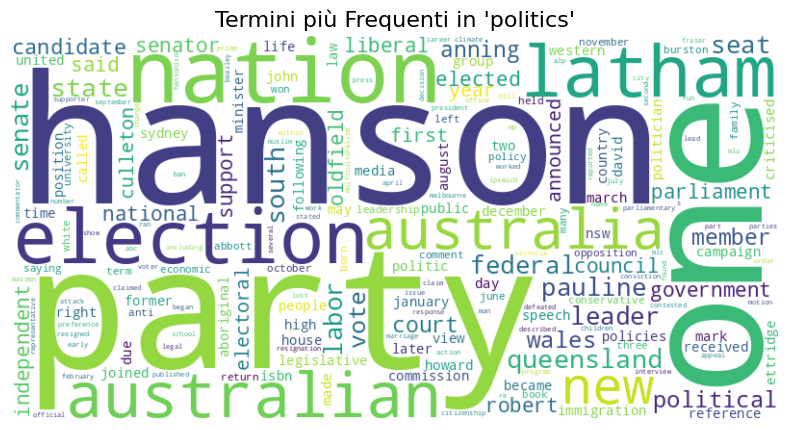


Generazione Word Cloud per la categoria: 'economics'


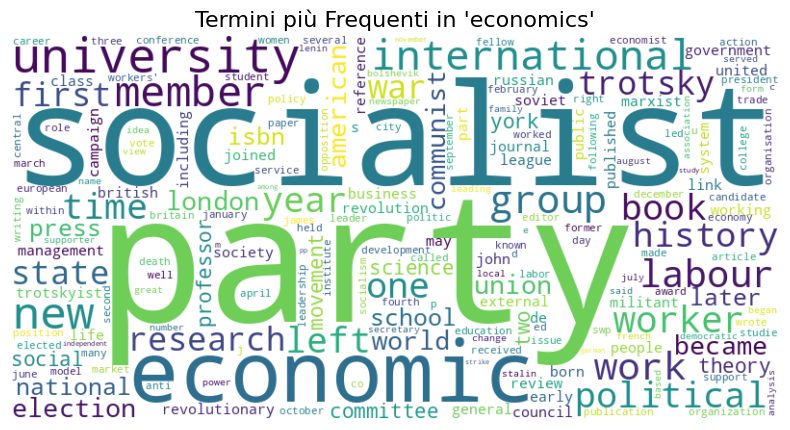

In [4]:
#conteggio articoli per categoria
print("\n>>>>>>>nalisi descrittiva")
print("Conteggio degli articoli per categoria:")
category_counts = df.groupBy("label").count().orderBy(col("count").desc())
category_counts.show()

#Per visualizzare i dati con Matplotlib/Seaborn, bisogna prima portarli dal cluster spark al
#driver node convertendoli in un dataframe pandas.
# Visualizzazione del conteggio
category_counts_pd = category_counts.toPandas()
plt.figure(figsize=(10, 6))

#assegnazione esplicita 'label' a 'hue' per gestire i colori
sns.barplot(x="count", y="label", data=category_counts_pd, palette="viridis", hue="label", legend=False)

plt.title("Numero di articoli per categoria", fontsize=16)
plt.xlabel("Numero di articoli", fontsize=12)
plt.ylabel("Categoria", fontsize=12)
plt.show()


print("\n>>>>><  pulizia dei record con campo 'documents' nullo...")
record_count_before = df.count()
print(f">>>Record totali prima della pulizia: {record_count_before}")

# rimozione righe dove 'documents' è nullo
df = df.na.drop(subset=["documents"])

record_count_after = df.count()
print(f">>>>>>Record totali dopo la pulizia: {record_count_after}")
print(f">>>>>>>> Record rimossi: {record_count_before - record_count_after}")
print("Pulizia andata a buon fine. Da ora in poi uso il dataframe pulito")

#Analisi della lunghezza degli articoli
# creazione colonna 'word_count' contando le parole nella colonna 'documents'
#funzione split: divide il testo in base agli spazi; size conta gli elementi dell'array risultante
df_with_word_count = df.withColumn("word_count", size(split(col("documents"), " ")))

length_analysis = df_with_word_count.groupBy("label").agg(
    min("word_count").alias("Min Word Count"),
    max("word_count").alias("Max Word Count"),
    round(avg("word_count"), 2).alias("Avg Word Count") # Arrotondiamo la media
).orderBy(col("Avg Word Count").desc())

print("\n>>>><<Analisi della lunghezza degli articoli per categoria:")
length_analysis.show()


#generazione delle nuvole di parole (word clouds)
# preparazione dati per le word clouds
tokenizer_wc = Tokenizer(inputCol="documents", outputCol="words_token")
df_tokenized_wc = tokenizer_wc.transform(df.select("label", "documents"))

stopwords_en = StopWordsRemover.loadDefaultStopWords("english")
remover_wc = StopWordsRemover(inputCol="words_token", outputCol="words_clean", stopWords=stopwords_en)
df_clean_wc = remover_wc.transform(df_tokenized_wc)

#funzione per generare e mostrare una word cloud per una data categoria
def generate_wordcloud_for_category(df_clean, category_name):
    """Filtra il df per una categoria, raccoglie le parole e genera una word cloud."""
    print(f"\nGenerazione Word Cloud per la categoria: '{category_name}'")

    # Raccogliamo tutte le parole per la categoria specifica in una singola stringa
    words_for_category = df_clean.filter(col("label") == category_name) \
                                 .select(explode("words_clean").alias("word")) \
                                 .rdd.flatMap(lambda x: x).collect()

    text = " ".join(words_for_category)

    wordcloud = WordCloud(width=800, height=400, background_color="white", collocations=False).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Termini più Frequenti in '{category_name}'", fontsize=16)
    plt.show()

#generazione word cloud per alcune categorie
generate_wordcloud_for_category(df_clean_wc, "science")
generate_wordcloud_for_category(df_clean_wc, "politics")
generate_wordcloud_for_category(df_clean_wc, "economics")



# Classificatore

In [5]:
#preparazione dati per il modello
# unione 'summary' e 'documents' in un'unica colonna 'text' per massimizzare le informazioni
df_model = df.withColumn("text", concat_ws(" ", col("summary"), col("documents")))

#divisione del dataset in training e test set
(training_data, test_data) = df_model.randomSplit([0.8, 0.2], seed=42)

print(f"\n>>>>>>>Numero di record per l'addestramento: {training_data.count()}")
print(f">>>>>>Numero di record per il test: {test_data.count()}")

#definizione della pipeline

#1) conversione etichette testuali in indici numerici
label_indexer = StringIndexer(inputCol="label", outputCol="label_indexed")

#2)tokenizer (divide il testo in parole)
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# 3) stopWordsRemover (rimuove le parole comuni, ovvero stop words, in inglese)
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=stopwords_en)

# 4) HashingTF (converte le parole in vettori numerici a dimensione fissa)
# numFeatures è la dimensione del vettore
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=2**14)

# 5) IDF (inverse document frequency) per pesare i termini nel vettore
idf = IDF(inputCol="rawFeatures", outputCol="features")

# 6) algoritmo di classificazione (regressione logistica)
lr = LogisticRegression(featuresCol="features", labelCol="label_indexed")

#pipeline
pipeline = Pipeline(stages=[label_indexer, tokenizer, remover, hashingTF, idf, lr])

#addestramento modello
print("\n>>>>>< addestramento della pipeline...")
model = pipeline.fit(training_data)
print(">>>>>Addestramento completato con successo!")




>>>>>>>Numero di record per l'addestramento: 121687
>>>>>>Numero di record per il test: 30617

>>>>>< addestramento della pipeline...
>>>>>Addestramento completato con successo!


# Valutazione del modello

In [6]:
#previsioni
print("\n>>>>>>>>>>>>Valutazione del modello sul test set...")
predictions = model.transform(test_data)

#mostriamo alcune previsioni per un controllo qualitativo
predictions.select("label", "prediction", "label_indexed").show(10)

#calcolo metriche
# uso MulticlassClassificationEvaluator per le metriche standard
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label_indexed", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_indexed", predictionCol="prediction", metricName="f1")

accuracy = evaluator_accuracy.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print(f"\n>>>>>Accuracy sul test set = {accuracy:.2%}")
print(f">>>>>>>>>>F1-Score (pesato) sul test set = {f1_score:.2%}")

#matrice di confusione e metriche per classe
#uso MulticlassMetrics per un'analisi più dettagliata

#etichette reali e predette come RDD (formato richiesto da MulticlassMetrics)
preds_and_labels = predictions.select("prediction", "label_indexed").rdd.map(
    lambda row: (float(row.prediction), float(row.label_indexed))
)

metrics = MulticlassMetrics(preds_and_labels)
confusion_matrix = metrics.confusionMatrix().toArray()

#nomi delle etichette dal modello addestrato per una migliore leggibilità
#accedo allo stadio 'stringindexer' del modello della pipeline per recuperare le etichette
label_names = model.stages[0].labels

print("\n>>>>>><Matrice di confusione:")
df_confusion = pd.DataFrame(confusion_matrix, index=label_names, columns=label_names)
print(df_confusion)

# metriche per ogni singola classe
print("\n>>>>>> Metriche di Performance per Classe")
for i, label in enumerate(label_names):
    print(f"\nStatistiche per la classe '{label}':")
    print(f"  Precision = {metrics.precision(float(i)):.2f}")
    print(f"  Recall    = {metrics.recall(float(i)):.2f}")
    print(f"  F1 Score  = {metrics.fMeasure(float(i)):.2f}")




>>>>>>>>>>>>Valutazione del modello sul test set...
+---------+----------+-------------+
|    label|prediction|label_indexed|
+---------+----------+-------------+
|   energy|       8.0|          8.0|
| medicine|      12.0|         12.0|
| politics|       2.0|          0.0|
|    trade|      13.0|         13.0|
|  culture|       2.0|          3.0|
|transport|       1.0|          4.0|
|   energy|       1.0|          8.0|
|  finance|      14.0|         14.0|
|     pets|       9.0|          9.0|
| politics|       0.0|          0.0|
+---------+----------+-------------+
only showing top 10 rows


>>>>>Accuracy sul test set = 92.70%
>>>>>>>>>>F1-Score (pesato) sul test set = 92.70%


/content/spark-3.5.1-bin-hadoop3/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



>>>>>><Matrice di confusione:
             politics  engineering  humanities  culture  transport  economics  \
politics       2236.0          4.0         6.0      1.0        0.0        1.0   
engineering       0.0       1805.0        11.0     10.0       25.0       10.0   
humanities        5.0         16.0      1866.0     11.0        2.0       16.0   
culture           2.0          5.0        15.0   1967.0        2.0        1.0   
transport         2.0         27.0         3.0      1.0     1932.0        0.0   
economics         1.0         15.0        19.0      3.0        0.0     1940.0   
science           3.0         24.0        10.0      2.0       23.0        4.0   
technology        0.0         13.0         8.0      3.0        2.0        9.0   
energy            5.0         12.0         2.0      1.0        6.0        2.0   
pets              0.0          7.0         3.0      1.0        0.0        1.0   
sports            1.0          8.0         1.0      6.0        1.0        1.0 

**Commento dei risultati**<br>
Osservando le metriche di performance, si nota subito che le classi 'research' e 'medicine' hanno un F1-Score significativamente più basso rispetto alle altre.
Inoltre, nella matrice di confusione, 316 articoli di 'research' sono stati erroneamente classificati come 'medicine' e, quasi lo stesso numero, 323 articoli di 'medicine', sono stati classificati come 'research'.<br>
Cosa significa? Questo non è un errore del modello, ma una scoperta sul dataset. Indica una forte sovrapposizione tematica e lessicale tra gli articoli delle due categorie. Molti articoli di ricerca medica utilizzano un vocabolario quasi identico a quello di articoli di medicina generale.<br>
<br>
<br>
<br>
La word cloud per 'economics' è sorprendente. Invece di termini come "market", "price", "supply", "demand", i termini più prominenti sono parole come "socialist" e "party".<br>
Questo suggerisce che il campione di articoli nella categoria 'economics' potrebbe essere sbilanciato verso la storia del pensiero economico-politico (es. Marxismo, Socialismo) piuttosto che verso la teoria economica moderna. Di conseguenza, il modello imparerà a classificare come "economics" testi che parlano di partiti socialisti. Questo è un potenziale bias nel dataset che hai indirettamente scoperto.